**Name:** \_\_HAN Zhuo\_\_

**EID:** \_\_zhuohan3\_\_

# CS5489 - Tutorial 8
## Image Segmentation using Clustering

In this tutorial you will use clustering algorithms to generate a segmentation of an image.  An image segmentation is a separation of an image into regions belonging to distinct objects.
First we need to initialize Python.  Run the below cell.

In [1]:
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('jpg')
# jpg is better for images in this tutorial
import matplotlib.pyplot as plt
import matplotlib
from numpy import *
from sklearn import *
import glob
import os
import csv
import string
import skimage.io
import skimage.color
import skimage.util
random.seed(100)

##  Loading Data and Pre-processing
Next we need to load the data.  Download `imgdb.zip`, and unzip it in the same directory as this ipynb file.  Then run the following cell to load the image data.

In [2]:
import warnings

filelist = glob.glob('imgdb/jpg/*.jpg')
gtpath   = 'imgdb/gtruth/'
if len(filelist) == 0:
    raise FileNotFoundError("Could not find imgdb directory!  " + 
               "Make sure you put it here: " + os.getcwd() )
else:
    imgdata = []
    gtdata  = []
    
    # load image data
    for f in filelist:
        # load image - byte [0 to 255]
        img = skimage.io.imread(f)
        
        (fdir1, fname)  = os.path.split(f)        

        # load GT segmentation (non-consecutive integers)
        gname = gtpath + fname[:-4] + "-gt.png"
        gtimg = skimage.io.imread(gname)
        
        # convert to consecutive integers
        cl = unique(gtimg)
        gtimg0 = gtimg.copy().astype(float64)
        for i in range(len(cl)):
            gtimg0[gtimg==cl[i]] = i
        
        imgdata.append(img)
        gtdata.append(gtimg0)
print(len(imgdata))

14


There are 14 images.  Each image also has a ground-truth segmentation that was created by a human annotation.  Here is an example:

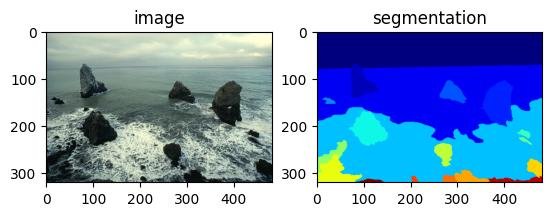

In [3]:
plt.subplot(1,2,1)
plt.imshow(imgdata[6], aspect='equal')
plt.title('image')
plt.subplot(1,2,2)
plt.imshow(gtdata[6], aspect='equal', cmap='jet')
plt.title('segmentation');

##  Clustering with Color Features
To segment an image, we will extract features from each pixel location.  Then, we cluster the extracted features into groups.  Pixel location that are clustered into the same group form a segment.

For the features, we will use the "Lab" colorspace, rather than the RGB colors.  Also, we will ignore the "L" feature, which is brightness, resulting in a 2-dimensional color feature space (a, b). Here are a few helper functions: 1) extract Lab features along a regular grid on the image; 2) convert cluster labels into a segmentation image; 3) color a segmentation image using colors from the original image.

In [4]:
def getfeatures(img, segm=None, stepsize=7, use_loc = False):
    """
    getfeatures - extract features from an image
     [X, Y, L] = getfeatures(img, stepsize)
     INPUT
     img      - the image   [type = np.ndarray or Image]
     segm     - the gt segmentation (optional)
     stepsize - window stepsize
     OUTPUT
      X   - the features: each row is a feature vector  [type = np.ndarray]
      Y   - the GT segment labels for each feature (if segm is provided)
      L   - dictionary containing location information of each feature
    """
    winsize = 7 # ensure it is an odd number
    if stepsize > winsize:
        raise Exception('stepsize larger than window size')
    # convert to LAB
    yimg = skimage.color.rgb2lab(img)

    offset = floor((winsize-1)/2)
    sy,sx, sc = img.shape

    if use_loc:
        Xdim = 4
    else:
        Xdim = 2
    
    # extract window patches with stepsize
    patches = skimage.util.view_as_windows(yimg, (winsize, winsize, 3), step=stepsize)    
    psize = patches.shape
    
    # get coordinates of windows
    rangex = arange(psize[1])*stepsize + offset
    rangey = arange(psize[0])*stepsize + offset

    X = zeros((psize[0] * psize[1], Xdim));
    
    if segm is None:
        Y = None
    else:
        Y = zeros((X.shape[0],))
    
    i = 0
    for x in range(psize[1]):
        for y in range(psize[0]):
            myu = mean(patches[y,x,0,:,:,1].flatten())
            myv = mean(patches[y,x,0,:,:,2].flatten())
            myy = int(rangey[y])
            myx = int(rangex[x])
            
            if use_loc:
                X[i,:] = [myu, myv, myx, myy]
            else:
                X[i,:] = [myu, myv]
                
            if Y is not None:
                Y[i] = segm[myy, myx]
                
            i = i + 1 
    
    L = {'rangex':rangex, 'rangey':rangey, 'offset':offset, 'sx':sx, 'sy':sy, \
         'stepsize':stepsize, 'winsize':winsize}
    return X, Y, L

def labels2seg(Y,L):
    """
    labels2segm - form a segmentation image using cluster labels
    segm = labels2segm(Y, L)
    Y - cluster labels for each location
    L - location dictionary from getfeatures
    segm - output segmentation image
    """
    segm = zeros((L['sy'], L['sx']))
    # <= offset if floor((winsize-1)/2)>= floor(stepsize/2) 
    rstep = int(floor(L['stepsize']/2.0)) 
    stepbox = range(-rstep, L['stepsize'] - rstep)
    rx = asarray(L['rangex'], dtype=int) + int(L['offset'])
    ry = asarray(L['rangey'], dtype=int) + int(L['offset'])
    Y_reshaped = Y.reshape((ry.size, rx.size),order='F')
    for i in stepbox:
        for j in stepbox:
            segm[ix_(ry + j, rx + i)] = Y_reshaped
    ## Now fil in the borders if they are missing
    minx = min(rx) + stepbox[0] - 1
    maxx = max(rx) + stepbox[-1] + 1
    miny = min(ry) + stepbox[0] - 1
    maxy = max(ry) + stepbox[-1] + 1

    if 0 <= minx:
        ## fill in left edge
        segm[:, 0:minx+1] = segm[:,minx+1].reshape((-1,1))
    if maxx < L['sx']:
        ## fill in right edge
        segm[:,maxx:] = segm[:,maxx-1].reshape((-1,1))
    if 0 < miny:
        ## fill in top edge
        segm[0:miny+1,:] = segm[miny+1,:].reshape((1,-1))
    if maxy < L['sy']:
        ## fill in bottom edge
        segm[maxy:,:] = segm[maxy-1,:].reshape((1,-1))
    return segm    

def colorsegms(segm, img):
    """
    colorsegm - color a segmentation based on the image
    csegm = colorsegm(segm, img)
    segm = the segmentation image  [type = np.ndarray]
    img = the original image    [type = np.ndarray (or Image)]
    csegm = the colored segmentation -- each segment is colored based on the 
            average pixel color within the segment.
    """
    img = asarray(img).copy()
    if segm.shape[0:2] != img.shape[0:2]:
        raise Exception('The shape of segmentation and image are not consistent') 
    rimg, gimg, bimg = img[:,:,0], img[:,:,1], img[:,:,2]
    for i in range(0, int(max(segm.flatten())) + 1):
        # assume label starts from 1
        ind = (segm == i)
        rimg[ind] = mean(rimg[ind].flatten())
        gimg[ind] = mean(gimg[ind].flatten())
        bimg[ind] = mean(bimg[ind].flatten())
    # handle outliers from DBSCAN
    ind = (segm == -1)
    rimg[ind] = 0
    gimg[ind] = 0
    bimg[ind] = 0
    return img

Next, we use the `getfeatures` function to extract features from an image.  `X` contains the feature vectors. `L` contains information about where each features was extracted, which is used later generate the segmentation.

(3060, 2)


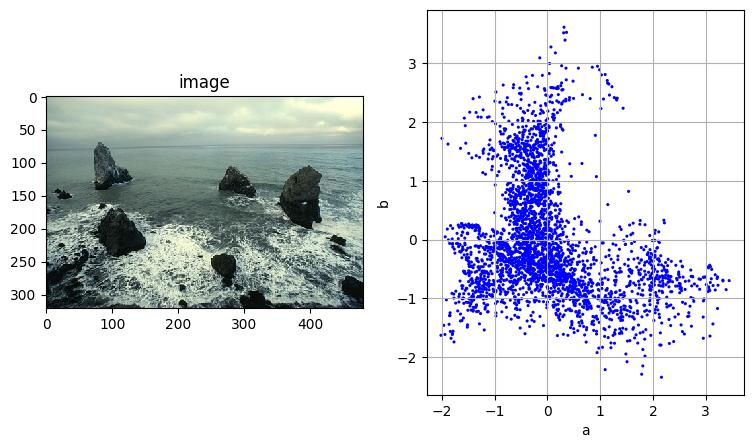

In [17]:
# image to use
img = imgdata[6]
gt  = gtdata[6]

# extract features, each row is a feature vector
Xo,Ytrue, L = getfeatures(img, gt)
print(Xo.shape)

# normalize features
scaler = preprocessing.StandardScaler()  
X = scaler.fit_transform(Xo)

# view the image
plt.figure(figsize=(9,5))
plt.subplot(1,2,1)
plt.imshow(img, interpolation='nearest')
plt.title("image")

# view the features
plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c='b', s=5, edgecolor='none')
plt.ylabel('b'); plt.xlabel('a'); plt.grid(True)

Here is the segmented image, with the segment labels shown as colors.  The goal is to recoever these labels using clustering. 

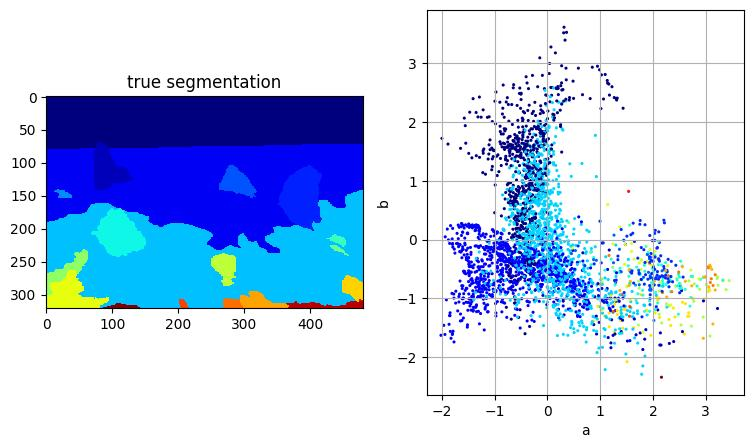

In [18]:
# view the image
plt.figure(figsize=(9,5))

plt.subplot(1,2,1)
plt.imshow(gt, interpolation='nearest', cmap='jet')
plt.title("true segmentation")

# view the features
plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=Ytrue, s=5, edgecolor='none', cmap='jet')
plt.ylabel('b'); plt.xlabel('a'); plt.grid(True)

Now use a clustering algorithm to group the data into 5 clusters.

In [19]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
Y = agg.fit_predict(X)

Once you have the cluster labels (Y), use the below code to generate the segmentation image and view it.  You can also view the scatter plot with `showscatter`.

In [20]:
def showsegm(segm, img):
    "show a segmentation"
    
    # fill segmentation with colors from the image
    csegm = colorsegms(segm, img)
    
    # view the images, segmentation, and ground-truth
    plt.figure(figsize=(12,5))
    plt.subplot(1,3,1)
    plt.imshow(img, interpolation='nearest')
    plt.title('image')
    plt.subplot(1,3,2)
    plt.imshow(segm, interpolation='nearest', cmap='jet')
    plt.title('segmentation')
    plt.subplot(1,3,3)
    plt.imshow(gt, interpolation='nearest', cmap='jet')
    plt.title("ground truth")
    
    return segm

def showscatter(X,Y):
    "show a scatter plot of clusters"
    
    if X.shape[1] == 2:
        plt.figure()
        plt.scatter(X[:,0], X[:,1], c=Y, s=5, edgecolor='none', cmap='jet')
        plt.grid(True)
        plt.xlabel('a')
        plt.ylabel('b')
    else:
        plt.figure(figsize=(12,3))

        plt.subplot(1,4,1)
        plt.scatter(X[:,0], X[:,1], c=Y, s=5, edgecolor='none', cmap='jet')
        plt.xlabel('a'); plt.ylabel('b'); plt.grid(True)

        plt.subplot(1,4,2)
        plt.scatter(X[:,2], X[:,3], c=Y, s=5, edgecolor='none', cmap='jet')
        plt.xlabel('x-pos'); plt.ylabel('y-pos'); plt.grid(True)

        plt.subplot(1,4,3)
        plt.scatter(X[:,2], X[:,0], c=Y, s=5, edgecolor='none', cmap='jet')
        plt.xlabel('x-pos'); plt.ylabel('a'); plt.grid(True)

        plt.subplot(1,4,4)
        plt.scatter(X[:,3], X[:,1], c=Y, s=5, edgecolor='none', cmap='jet')
        plt.xlabel('y-pos'); plt.ylabel('b'); plt.grid(True)
        
        plt.tight_layout()

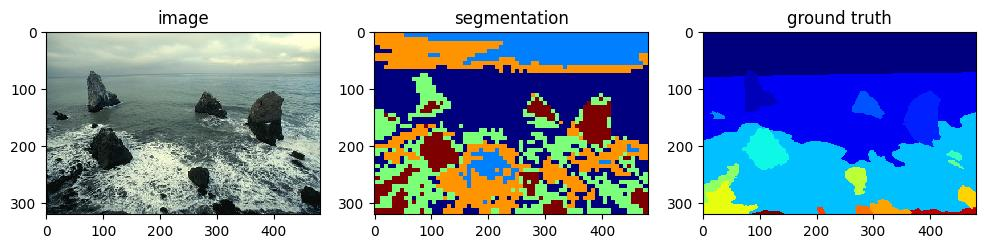

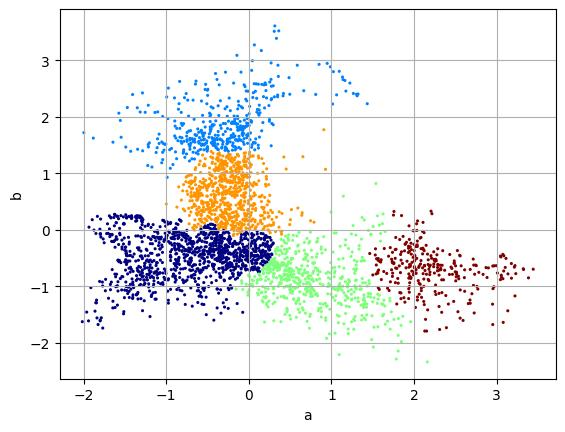

In [21]:
# convert cluster labels to a segmentation image
segm = labels2seg(Y, L)

# show the segmentation
showsegm(segm, img)

# show the scatter plot
showscatter(X,Y)

Next we evaluate the segmentation with the ground-truth provided by a human annotator.  We cannot just check that the cluster assignments for each pixel are the same, since the cluster indices can be permuted.  We will use the _Adjusted Rand Index_, which calculates how often a pair of pixels is assigned correctly to the same cluster or not.  Use the below code to calculate the ARI. Higher values are better, and the maximum value is 1. 

In [22]:
# calculate ARI
#ari = metrics.adjusted_rand_score(gt.flatten(), segm.flatten())
ari = metrics.adjusted_rand_score(Ytrue, Y)
print("ARI =",ari)

ARI = 0.2996686484730363


Try different clustering algorithms and settings (K, bandwidth, etc) to get the best segmentation as measured by ARI. 

In [23]:
### INSERT YOUR CODE HERE
from sklearn.cluster import KMeans, SpectralClustering, MeanShift, estimate_bandwidth, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn import metrics
import numpy as np

results = []      
best_ari = -1.0
best_cfg = None
best_labels = None

# KMeans
for k in [3, 4, 5, 6, 7, 8]:
    for init in ['k-means++', 'random']:
        km = KMeans(
            n_clusters=k,
            init=init,
            n_init=10,
            random_state=0
        )
        Y = km.fit_predict(X)
        ari = metrics.adjusted_rand_score(Ytrue, Y)
        cfg = ("KMeans", {"K": k, "init": init})
        results.append((cfg, k, ari))
        if ari > best_ari:
            best_ari = ari
            best_cfg = cfg
            best_labels = Y

# GMM
for k in [3, 4, 5, 6, 7, 8]:
    for cov in ['full', 'diag', 'tied', 'spherical']:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            random_state=0
        )
        Y = gmm.fit_predict(X)
        ari = metrics.adjusted_rand_score(Ytrue, Y)
        cfg = ("GMM", {"K": k, "covariance_type": cov})
        results.append((cfg, k, ari))
        if ari > best_ari:
            best_ari = ari
            best_cfg = cfg
            best_labels = Y

# Spectral Clustering
for k in [3, 4, 5, 6, 7]:
    for nn in [5, 10, 15]:
        spec = SpectralClustering(
            n_clusters=k,
            n_neighbors=nn,
            affinity='nearest_neighbors',
            assign_labels='kmeans',
            random_state=0
        )
        Y = spec.fit_predict(X)
        ari = metrics.adjusted_rand_score(Ytrue, Y)
        cfg = ("Spectral", {"K": k, "n_neighbors": nn})
        results.append((cfg, k, ari))
        if ari > best_ari:
            best_ari = ari
            best_cfg = cfg
            best_labels = Y

# MeanShift
for q in [0.1, 0.2, 0.3]:
    bw = estimate_bandwidth(X, quantile=q, n_samples=500)
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    Y = ms.fit_predict(X)
    K_eff = len(np.unique(Y))
    ari = metrics.adjusted_rand_score(Ytrue, Y)
    cfg = ("MeanShift", {"quantile": q, "bandwidth": float(bw)})
    results.append((cfg, K_eff, ari))
    if ari > best_ari:
        best_ari = ari
        best_cfg = cfg
        best_labels = Y

# DBSCAN
for eps in [0.05, 0.1, 0.15, 0.2]:
    for msamp in [5, 10]:
        db = DBSCAN(eps=eps, min_samples=msamp)
        Y = db.fit_predict(X)
        K_eff = len(np.unique(Y))
        ari = metrics.adjusted_rand_score(Ytrue, Y)
        cfg = ("DBSCAN", {"eps": eps, "min_samples": msamp})
        results.append((cfg, K_eff, ari))
        if ari > best_ari:
            best_ari = ari
            best_cfg = cfg
            best_labels = Y

for (algo_name, params), K_eff, ari in sorted(results, key=lambda x: x[2], reverse=True):
    print(f"{algo_name:12s}  K_eff={K_eff:2d}, params={params}, ARI={ari:.4f}")

print("\n*** Best setting ***")
print("Algorithm & params:", best_cfg)
print("Best ARI:", best_ari)

GMM           K_eff= 4, params={'K': 4, 'covariance_type': 'full'}, ARI=0.2862
KMeans        K_eff= 4, params={'K': 4, 'init': 'k-means++'}, ARI=0.2804
KMeans        K_eff= 4, params={'K': 4, 'init': 'random'}, ARI=0.2804
GMM           K_eff= 3, params={'K': 3, 'covariance_type': 'diag'}, ARI=0.2797
KMeans        K_eff= 5, params={'K': 5, 'init': 'k-means++'}, ARI=0.2748
GMM           K_eff= 4, params={'K': 4, 'covariance_type': 'tied'}, ARI=0.2747
KMeans        K_eff= 5, params={'K': 5, 'init': 'random'}, ARI=0.2747
GMM           K_eff= 5, params={'K': 5, 'covariance_type': 'tied'}, ARI=0.2712
GMM           K_eff= 4, params={'K': 4, 'covariance_type': 'spherical'}, ARI=0.2700
GMM           K_eff= 3, params={'K': 3, 'covariance_type': 'full'}, ARI=0.2690
GMM           K_eff= 5, params={'K': 5, 'covariance_type': 'full'}, ARI=0.2688
GMM           K_eff= 5, params={'K': 5, 'covariance_type': 'spherical'}, ARI=0.2668
Spectral      K_eff= 4, params={'K': 4, 'n_neighbors': 10}, ARI=0.2644
G

In [24]:
from sklearn.cluster import AgglomerativeClustering
from sklearn import metrics

try:
    best_ari
except NameError:
    best_ari = -1.0
    best_cfg = None
    best_labels = None
    results = []

agg_results = []

Ks = [3, 4, 5, 6, 7, 8]
linkages = ['ward', 'complete', 'average', 'single']
distances = ['euclidean', 'manhattan', 'cosine']

for k in Ks:
    for link in linkages:
        if link == 'ward':
            agg = AgglomerativeClustering(
                n_clusters=k,
                linkage='ward'
            )
            Y = agg.fit_predict(X)
            ari = metrics.adjusted_rand_score(Ytrue, Y)
            cfg = ("Agglomerative",
                   {"K": k, "linkage": "ward", "metric": "euclidean"})
            agg_results.append((cfg, k, ari))
            results.append((cfg, k, ari))
            if ari > best_ari:
                best_ari = ari
                best_cfg = cfg
                best_labels = Y
        else:
            for dist in distances:
                agg = AgglomerativeClustering(
                    n_clusters=k,
                    linkage=link,
                    metric=dist
                )
                Y = agg.fit_predict(X)
                ari = metrics.adjusted_rand_score(Ytrue, Y)
                cfg = ("Agglomerative",
                       {"K": k, "linkage": link, "metric": dist})
                agg_results.append((cfg, k, ari))
                results.append((cfg, k, ari))
                if ari > best_ari:
                    best_ari = ari
                    best_cfg = cfg
                    best_labels = Y

for (algo_name, params), K_eff, ari in sorted(agg_results, key=lambda x: x[2], reverse=True):
    print(f"{algo_name:14s}  K={K_eff:2d}, params={params}, ARI={ari:.4f}")

print("\n*** Current global best (including previous algorithms) ***")
print("Best cfg:", best_cfg)
print("Best ARI:", best_ari)

Agglomerative   K= 5, params={'K': 5, 'linkage': 'ward', 'metric': 'euclidean'}, ARI=0.2997
Agglomerative   K= 4, params={'K': 4, 'linkage': 'complete', 'metric': 'euclidean'}, ARI=0.2886
Agglomerative   K= 3, params={'K': 3, 'linkage': 'complete', 'metric': 'manhattan'}, ARI=0.2870
Agglomerative   K= 3, params={'K': 3, 'linkage': 'ward', 'metric': 'euclidean'}, ARI=0.2827
Agglomerative   K= 4, params={'K': 4, 'linkage': 'average', 'metric': 'euclidean'}, ARI=0.2816
Agglomerative   K= 5, params={'K': 5, 'linkage': 'average', 'metric': 'euclidean'}, ARI=0.2785
Agglomerative   K= 5, params={'K': 5, 'linkage': 'complete', 'metric': 'euclidean'}, ARI=0.2765
Agglomerative   K= 4, params={'K': 4, 'linkage': 'average', 'metric': 'manhattan'}, ARI=0.2754
Agglomerative   K= 3, params={'K': 3, 'linkage': 'average', 'metric': 'manhattan'}, ARI=0.2753
Agglomerative   K= 3, params={'K': 3, 'linkage': 'complete', 'metric': 'euclidean'}, ARI=0.2751
Agglomerative   K= 7, params={'K': 7, 'linkage': 'av

ARI = 0.2996686484730363


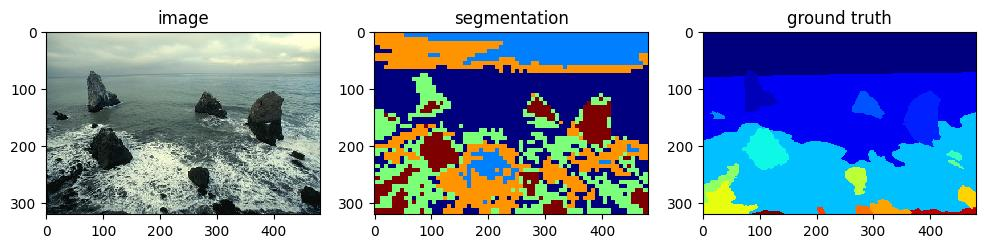

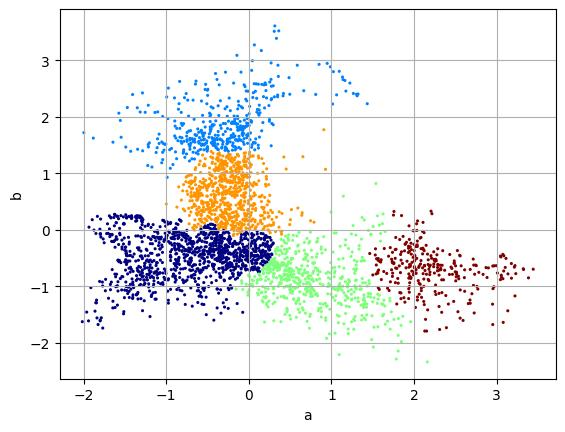

In [25]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
Y_best = agg.fit_predict(X) 

ari_best = metrics.adjusted_rand_score(Ytrue, Y_best)
print("ARI =", ari_best)

segm_best = labels2seg(Y_best, L)

showsegm(segm_best, img)
showscatter(X, Y_best)

_Which algorithm performs the best?  Why?_
- **INSERT YOUR ANSWER HERE**
- The best-performing algorithm in my experiments is Agglomerative Clustering with ward linkage, achieving the highest ``ARI = 0.2996686484730363`` among all clustering settings.
- The ward linkage criterion explicitly minimizes the variance within each cluster. Compared with other linkage choices (e.g., single, complete, average), ward generally gives cleaner boundaries and less noise, which leads to the highest ARI in our experiments.

## Color and Position Features
You may notice that the segmentation is not spatially smooth -- that is, there are some "loner" pixels that are not the same cluster as the surrounding pixels.  This is because we are only clustering color.  One way to fix this is to include the (x,y) coordinate of the pixel as part of the feature vector.  This way, clusters will have pixels that are spatially close together.

The below code extracts a 4-dimensional feature vector, where the first 2 features are the color channels and the last 2 features are the position.

In [40]:
# extract features with location
Xo,Ytrue,L = getfeatures(img, gt, use_loc=True)
print(Xo.shape)

# normalize features
scaler = preprocessing.StandardScaler()  
X = scaler.fit_transform(Xo)

# rescale position features
# larger values emphasize clustering by position more
X[:,2:4] *= 0.5

(3060, 4)


Here are plots of the 4 features.

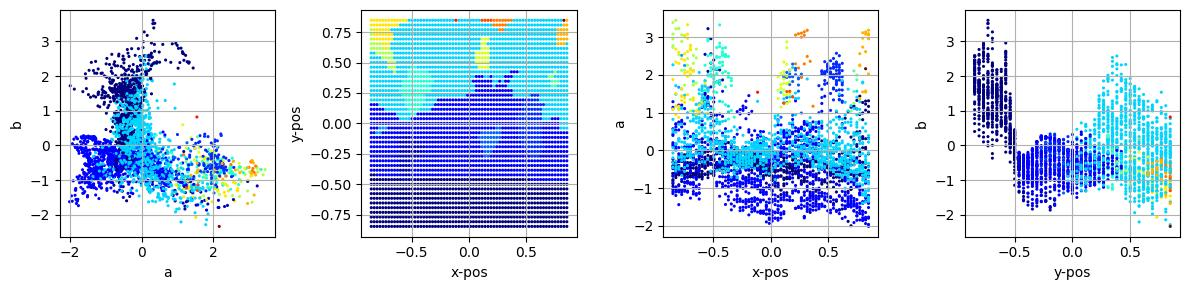

In [41]:
showscatter(X, Ytrue)

Run clustering algorithms on the 4-dimensional data.  Try different algorithms and parameters to get the best ARI.

In [42]:
### INSERT YOUR CODE HERE
from sklearn.cluster import KMeans, SpectralClustering, MeanShift, estimate_bandwidth, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn import metrics
import numpy as np

results = []      
best_ari = -1.0
best_cfg = None
best_labels = None

# KMeans
for k in [3, 4, 5, 6, 7, 8]:
    for init in ['k-means++', 'random']:
        km = KMeans(
            n_clusters=k,
            init=init,
            n_init=10,
            random_state=0
        )
        Y = km.fit_predict(X)
        ari = metrics.adjusted_rand_score(Ytrue, Y)
        cfg = ("KMeans", {"K": k, "init": init})
        results.append((cfg, k, ari))
        if ari > best_ari:
            best_ari = ari
            best_cfg = cfg
            best_labels = Y

# GMM
for k in [3, 4, 5, 6, 7, 8]:
    for cov in ['full', 'diag', 'tied', 'spherical']:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            random_state=0
        )
        Y = gmm.fit_predict(X)
        ari = metrics.adjusted_rand_score(Ytrue, Y)
        cfg = ("GMM", {"K": k, "covariance_type": cov})
        results.append((cfg, k, ari))
        if ari > best_ari:
            best_ari = ari
            best_cfg = cfg
            best_labels = Y

# Spectral Clustering
for k in [3, 4, 5, 6, 7]:
    for nn in [5, 10, 15]:
        spec = SpectralClustering(
            n_clusters=k,
            n_neighbors=nn,
            affinity='nearest_neighbors',
            assign_labels='kmeans',
            random_state=0
        )
        Y = spec.fit_predict(X)
        ari = metrics.adjusted_rand_score(Ytrue, Y)
        cfg = ("Spectral", {"K": k, "n_neighbors": nn})
        results.append((cfg, k, ari))
        if ari > best_ari:
            best_ari = ari
            best_cfg = cfg
            best_labels = Y

# MeanShift
for q in [0.1, 0.2, 0.3]:
    bw = estimate_bandwidth(X, quantile=q, n_samples=500)
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    Y = ms.fit_predict(X)
    K_eff = len(np.unique(Y))
    ari = metrics.adjusted_rand_score(Ytrue, Y)
    cfg = ("MeanShift", {"quantile": q, "bandwidth": float(bw)})
    results.append((cfg, K_eff, ari))
    if ari > best_ari:
        best_ari = ari
        best_cfg = cfg
        best_labels = Y

# DBSCAN
for eps in [0.05, 0.1, 0.15, 0.2]:
    for msamp in [5, 10]:
        db = DBSCAN(eps=eps, min_samples=msamp)
        Y = db.fit_predict(X)
        K_eff = len(np.unique(Y))
        ari = metrics.adjusted_rand_score(Ytrue, Y)
        cfg = ("DBSCAN", {"eps": eps, "min_samples": msamp})
        results.append((cfg, K_eff, ari))
        if ari > best_ari:
            best_ari = ari
            best_cfg = cfg
            best_labels = Y

for (algo_name, params), K_eff, ari in sorted(results, key=lambda x: x[2], reverse=True):
    print(f"{algo_name:12s}  K_eff={K_eff:2d}, params={params}, ARI={ari:.4f}")

print("\n*** Best setting ***")
print("Algorithm & params:", best_cfg)
print("Best ARI:", best_ari)

/home/hanzhuo/miniconda3/envs/hz/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/hanzhuo/miniconda3/envs/hz/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/hanzhuo/miniconda3/envs/hz/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/hanzhuo/miniconda3/envs/hz/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/hanzhuo/miniconda3/envs/hz/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, sp

GMM           K_eff= 6, params={'K': 6, 'covariance_type': 'full'}, ARI=0.5071
GMM           K_eff= 4, params={'K': 4, 'covariance_type': 'tied'}, ARI=0.4990
GMM           K_eff= 4, params={'K': 4, 'covariance_type': 'full'}, ARI=0.4974
GMM           K_eff= 5, params={'K': 5, 'covariance_type': 'full'}, ARI=0.4603
GMM           K_eff= 4, params={'K': 4, 'covariance_type': 'diag'}, ARI=0.4486
Spectral      K_eff= 4, params={'K': 4, 'n_neighbors': 10}, ARI=0.4392
Spectral      K_eff= 5, params={'K': 5, 'n_neighbors': 15}, ARI=0.4381
Spectral      K_eff= 4, params={'K': 4, 'n_neighbors': 15}, ARI=0.4298
GMM           K_eff= 7, params={'K': 7, 'covariance_type': 'diag'}, ARI=0.4248
Spectral      K_eff= 5, params={'K': 5, 'n_neighbors': 5}, ARI=0.4235
GMM           K_eff= 5, params={'K': 5, 'covariance_type': 'diag'}, ARI=0.4234
GMM           K_eff= 5, params={'K': 5, 'covariance_type': 'tied'}, ARI=0.4147
GMM           K_eff= 7, params={'K': 7, 'covariance_type': 'full'}, ARI=0.4129
GMM   

In [43]:
from sklearn.cluster import AgglomerativeClustering
from sklearn import metrics

try:
    best_ari
except NameError:
    best_ari = -1.0
    best_cfg = None
    best_labels = None
    results = []

agg_results = []

Ks = [3, 4, 5, 6, 7, 8]
linkages = ['ward', 'complete', 'average', 'single']
distances = ['euclidean', 'manhattan', 'cosine']

for k in Ks:
    for link in linkages:
        if link == 'ward':
            agg = AgglomerativeClustering(
                n_clusters=k,
                linkage='ward'
            )
            Y = agg.fit_predict(X)
            ari = metrics.adjusted_rand_score(Ytrue, Y)
            cfg = ("Agglomerative",
                   {"K": k, "linkage": "ward", "metric": "euclidean"})
            agg_results.append((cfg, k, ari))
            results.append((cfg, k, ari))
            if ari > best_ari:
                best_ari = ari
                best_cfg = cfg
                best_labels = Y
        else:
            for dist in distances:
                agg = AgglomerativeClustering(
                    n_clusters=k,
                    linkage=link,
                    metric=dist
                )
                Y = agg.fit_predict(X)
                ari = metrics.adjusted_rand_score(Ytrue, Y)
                cfg = ("Agglomerative",
                       {"K": k, "linkage": link, "metric": dist})
                agg_results.append((cfg, k, ari))
                results.append((cfg, k, ari))
                if ari > best_ari:
                    best_ari = ari
                    best_cfg = cfg
                    best_labels = Y

for (algo_name, params), K_eff, ari in sorted(agg_results, key=lambda x: x[2], reverse=True):
    print(f"{algo_name:14s}  K={K_eff:2d}, params={params}, ARI={ari:.4f}")

print("\n*** Current global best (including previous algorithms) ***")
print("Best cfg:", best_cfg)
print("Best ARI:", best_ari)

Agglomerative   K= 8, params={'K': 8, 'linkage': 'average', 'metric': 'manhattan'}, ARI=0.4626
Agglomerative   K= 7, params={'K': 7, 'linkage': 'average', 'metric': 'manhattan'}, ARI=0.4566
Agglomerative   K= 8, params={'K': 8, 'linkage': 'average', 'metric': 'euclidean'}, ARI=0.4320
Agglomerative   K= 6, params={'K': 6, 'linkage': 'average', 'metric': 'manhattan'}, ARI=0.4285
Agglomerative   K= 8, params={'K': 8, 'linkage': 'average', 'metric': 'cosine'}, ARI=0.3912
Agglomerative   K= 3, params={'K': 3, 'linkage': 'average', 'metric': 'manhattan'}, ARI=0.3784
Agglomerative   K= 5, params={'K': 5, 'linkage': 'ward', 'metric': 'euclidean'}, ARI=0.3746
Agglomerative   K= 4, params={'K': 4, 'linkage': 'average', 'metric': 'cosine'}, ARI=0.3731
Agglomerative   K= 3, params={'K': 3, 'linkage': 'average', 'metric': 'cosine'}, ARI=0.3706
Agglomerative   K= 5, params={'K': 5, 'linkage': 'complete', 'metric': 'euclidean'}, ARI=0.3599
Agglomerative   K= 3, params={'K': 3, 'linkage': 'complete', 

_Which method performs the best?  Why?_
- **INSERT YOUR ANSWER HERE**
- The best-performing method is Gaussian Mixture Models (GMM) with ``K = 6`` and full covariance. It achieves the highest ``ARI = 0.5071496435529709``, significantly outperforming all other algorithms and also outperforming the best method without location features.
- GMM with full covariance is able to model clusters with different shapes, orientations, and correlations in the 4-dimensional feature space (color + normalized positions). This flexibility better matches the natural structure of image regions, which vary smoothly both in color and in spatial location. Therefore, GMM produces the segmentation that most closely aligns with the human-annotated ground truth.

_Does including the position features improve the segmentation results?_
- **INSERT YOUR ANSWER HERE**
- Yes, including position features improves the segmentation significantly, with the best ARI with position features being around 0.5071, while that without positional features being around 0.2997.